In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def noise_kernel_time(ti, tj, tau_c):
    return np.exp(-((ti - tj) ** 2) / (2 * tau_c ** 2))

Tmax = 10
delta_t = 0.01
tau_c = 10 #noise correlation time

time_grid = np.arange(0, Tmax + delta_t, delta_t)

# The covariance matrix
C = np.array([[noise_kernel_time(ti, tj, tau_c) for tj in time_grid] for ti in time_grid])

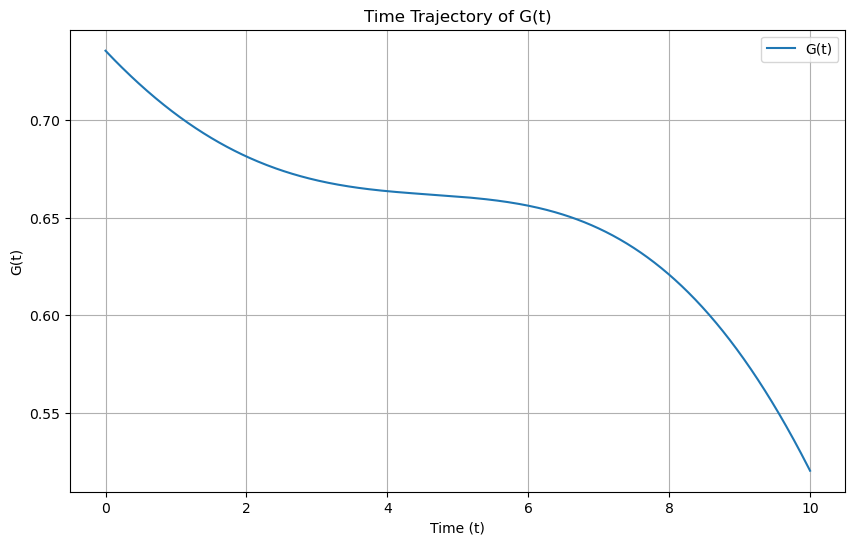

In [2]:
# Sample from the Gaussian process - single trajectory
G_t = np.random.multivariate_normal(np.zeros(len(time_grid)), C)

plt.figure(figsize=(10, 6))
plt.plot(time_grid, G_t, label='G(t)')
plt.title('Time Trajectory of G(t)')
plt.xlabel('Time (t)')
plt.ylabel('G(t)')
plt.grid(True)
plt.legend()
plt.show()


In [9]:
#Checking the statistics of the generated noise
N = 10000
G = np.random.multivariate_normal(np.zeros(len(time_grid)), C, N)


# Check mean
mean_G = np.max(np.abs(np.mean(G, axis=0)))
print("Mean of G(t) across samples:", mean_G)

Mean of G(t) across samples: 0.009474077511499914


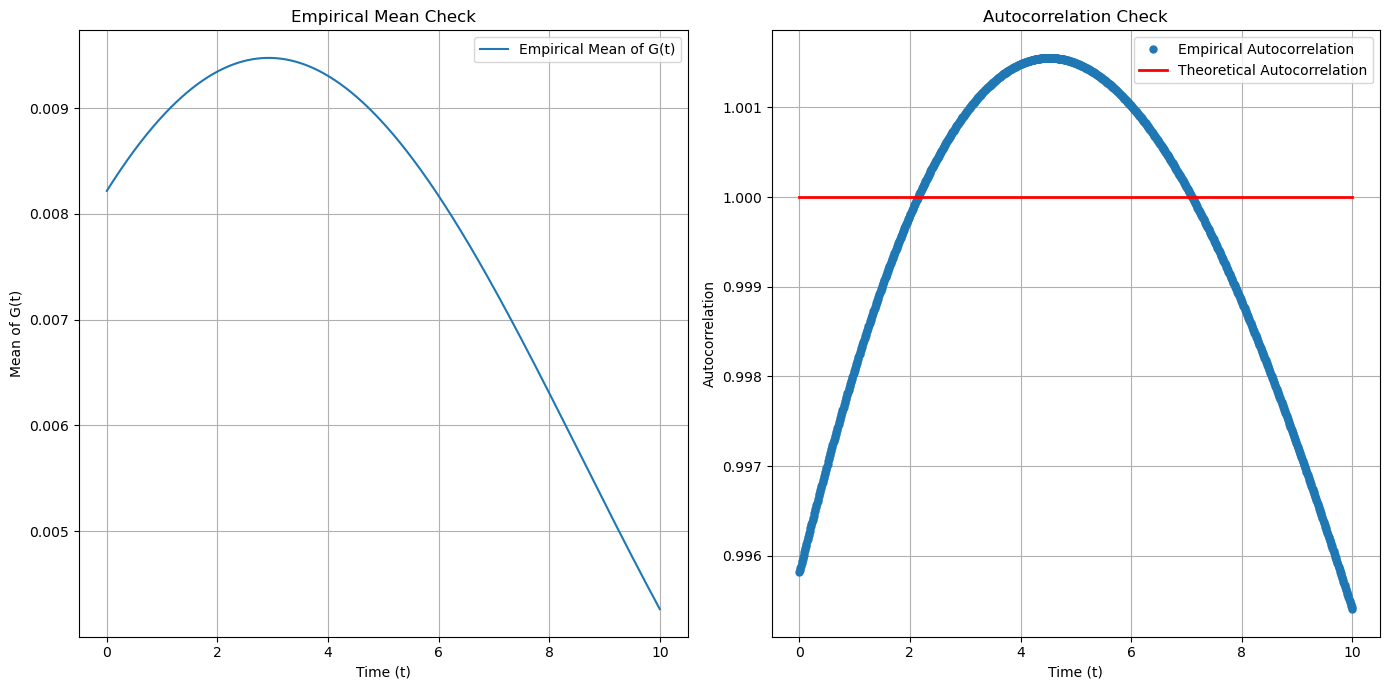

In [10]:
mean_G = np.mean(G, axis=0)
auto_corr_empirical = np.mean(G * G, axis=0)  # Ideally, should match C along the diagonal
# Theoretical autocorrelation at zero lag
auto_corr_theoretical = np.diag(C)

plt.figure(figsize=(14, 7))

# Mean plot
plt.subplot(1, 2, 1)
plt.plot(time_grid, mean_G, label='Empirical Mean of G(t)')
plt.title('Empirical Mean Check')
plt.xlabel('Time (t)')
plt.ylabel('Mean of G(t)')
plt.grid(True)
plt.legend()

# Autocorrelation plot
plt.subplot(1, 2, 2)
plt.plot(time_grid, auto_corr_empirical, 'o', label='Empirical Autocorrelation', markersize=5)
plt.plot(time_grid, auto_corr_theoretical, 'r', label='Theoretical Autocorrelation', linewidth=2)
plt.title('Autocorrelation Check')
plt.xlabel('Time (t)')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

/Users/pdolgirev/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/pdolgirev/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:184: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


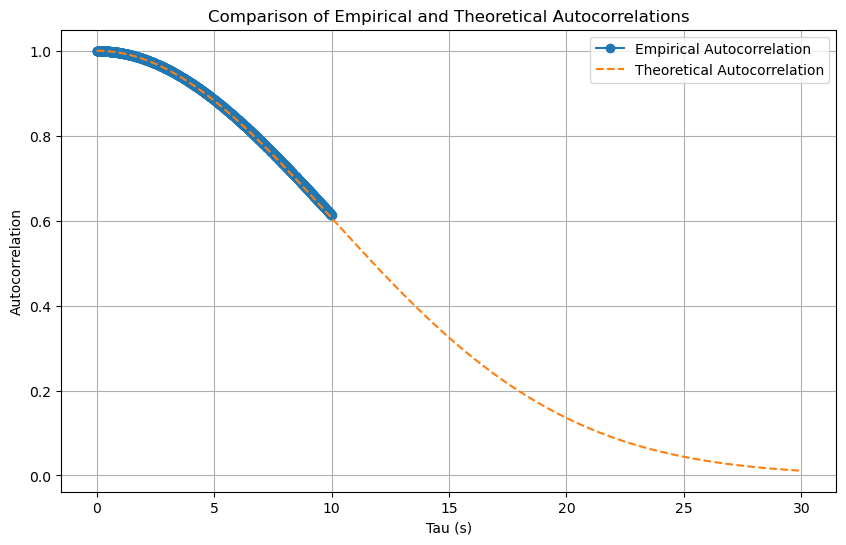

In [ ]:
tau_values = np.arange(0, int(30 / delta_t), 1)  
autocorrelations = []

for tau in tau_values:
    if tau == 0:
        autocorrelations.append(np.mean(G * G, axis=1).mean())
    else:
        autocorrelations.append(np.mean(G[:, :-tau] * G[:, tau:], axis=1).mean())

# Theoretical autocorrelation
theoretical_autocorrelations = np.exp(-((delta_t * tau_values)**2) / (2 * tau_c**2))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(delta_t * tau_values, autocorrelations, label='Empirical Autocorrelation', marker='o')
plt.plot(delta_t * tau_values, theoretical_autocorrelations, label='Theoretical Autocorrelation', linestyle='--')
plt.title('Comparison of Empirical and Theoretical Autocorrelations')
plt.xlabel('Tau (s)')
plt.ylabel('Autocorrelation')
plt.legend()
plt.grid(True)
plt.show()